# Black Marble NTL Toolkit: Simple Example

This notebook demonstrates how to use the toolkit to process daily Nighttime Light with an example of Ukraine.

In [1]:
import geopandas as gpd

from blackmarble_toolkit.methods.angular import QuadraticVZACorrection
from blackmarble_toolkit.methods.filters import (
    CloudSnowFilter,
    ModifiedZScoreOutlierRemoval,
)
from blackmarble_toolkit.pipeline import NTLPipeline
from blackmarble_toolkit.retrieval import BlackMarbleRetriever, gdf_to_geometry
from blackmarble_toolkit.utils import initialize_ee

## 1. Region of Interest

We will fetch the Level 2 administrative boundaries for Ukraine from [GADM](https://gadm.org/) and select a certain city in Southern Ukraine: Kryvyi Rig.

In [2]:
url = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_UKR_2.json.zip"
vfs_url = f"zip+{url}"

gdf = gpd.read_file(vfs_url)
gdf = gdf[gdf.NAME_2 == "KryvyiRig"]

gdf

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
90,UKR.5.8_1,UKR,Ukraine,UKR.5_1,Dnipropetrovs'k,Дніпропетро́вська,KryvyiRig,NA,NA,Misto,City,NA,UA.DP.KM,"MULTIPOLYGON (((33.2433 47.8638, 33.27 47.869,..."


## 2. Generating Unique IDs

Since the aggregation requires unique ID-s, which are integers, we need to generate one:

In [3]:
gdf = gdf.reset_index(names="geonameid")
id_dict = gdf[["geonameid", "NAME_2"]].set_index("NAME_2").to_dict()["geonameid"]
id_dict

{'KryvyiRig': 90}

## 3. Retrieving the Data

**Note on VNP46A1:** Because we are planning to use the `QuadraticVZACorrection` algorithm, we also need the sensor zenith angles. This means we *must* retrieve the **VNP46A1** (daily geometry/reflectance) product alongside the standard **VNP46A2** (NTL radiance) product. The A1 product contains the `Sensor_Zenith` band required for angular correction!

In [4]:
# we need to first authenticate with Google Earth Engine
initialize_ee()

In [5]:
start_date = "2020-01-01"
end_date = "2023-12-31"

region = gdf_to_geometry(gdf)

retriever = BlackMarbleRetriever()

ds_a2 = retriever.get_data(
    product="VNP46A2",
    start_date=start_date,
    end_date=end_date,
    region=region,
    bands=[
        "DNB_BRDF_Corrected_NTL",
        "Mandatory_Quality_Flag",
        "QF_Cloud_Mask",
        "Snow_Flag",
    ],
)

ds_a1 = retriever.get_data(
    product="VNP46A1",
    start_date=start_date,
    end_date=end_date,
    region=region,
    bands=["Sensor_Zenith"],
)

## 4. Preprocessing Pipeline
We instantiate the sequence of steps for our processing pipeline:
1. `CloudSnowFilter`: Masks out clouds and snow/ice based on QA flags.
2. `ModifiedZScoreOutlierRemoval`: Removes temporal outliers/spikes.
3. `Hu2024AAveraging`: Mitigates blooming and spatial noise by extracting and smoothing only the highly variable "mismatch" light.
4. `QuadraticVZACorrection`: Normalizes radiance variation caused by Viewing Zenith Angle (requires A1 data).

In [ ]:
steps = [CloudSnowFilter(), ModifiedZScoreOutlierRemoval(), QuadraticVZACorrection()]

pipeline = NTLPipeline(steps)
processed_ds = pipeline.run(
    ds=ds_a2, catalog={"VNP46A1": ds_a1}, cache_intermediates=True
)

## 5. Aggregation

We now aggregate our processed pixel data into the specific geographic regions defined by our vector shapes. This gives us a single time series per region.

In [ ]:
aggregated_results = pipeline.aggregate(gdf, geo_id_col="geonameid")

## 6. Plotting

Finally, we can visualize the aggregated time series for each step of our pipeline to see how the signal was cleaned with every step.

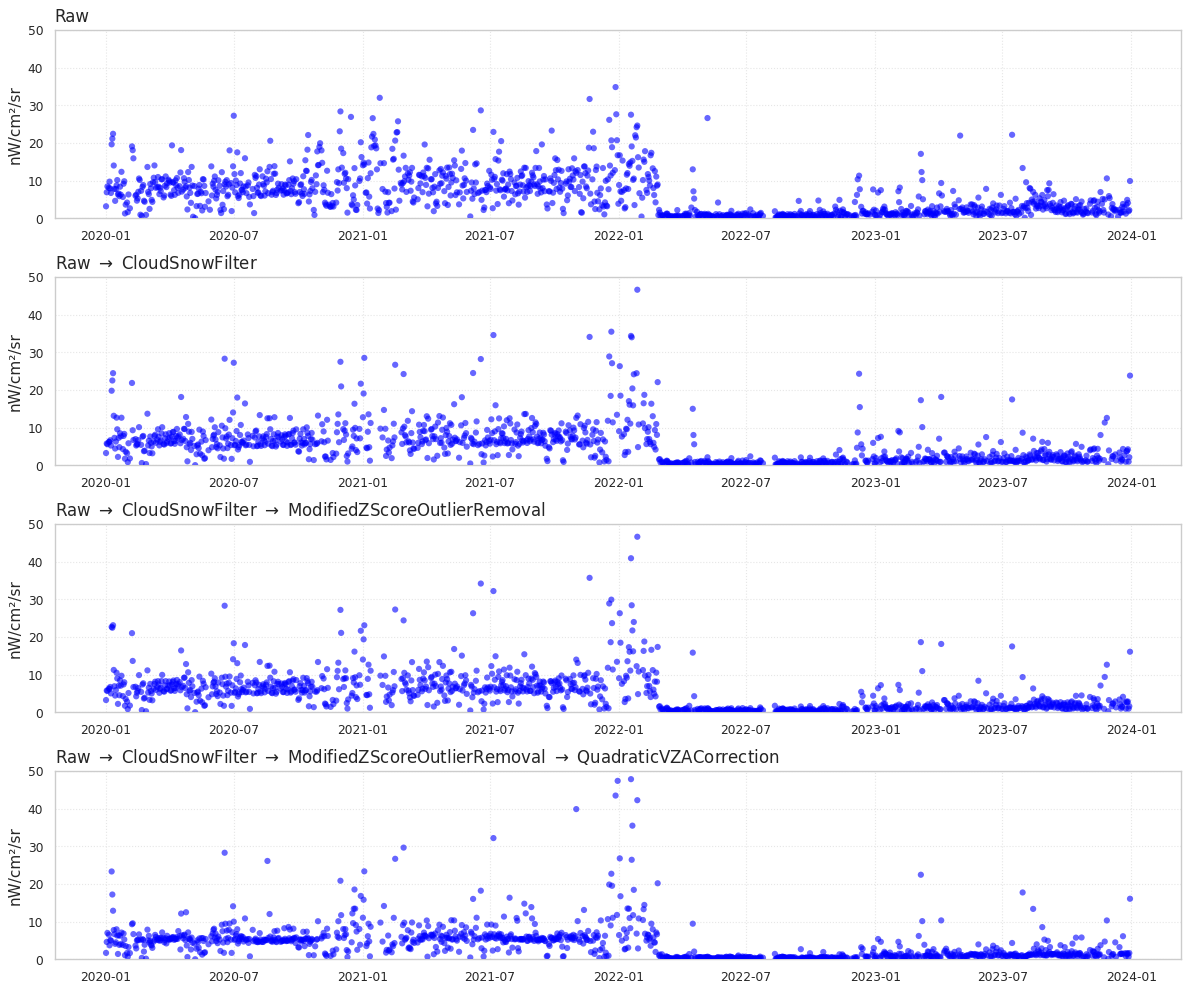

In [8]:
fig = pipeline.plot(indexers={"geonameid": id_dict["KryvyiRig"]}, y_max=50)